In [1]:
import sys
import os
import libcontext

In [2]:
import torch
import numpy as np
from typing import cast, List, Optional, Union
from tqdm import tqdm
import pandas as pd
import seaborn as sns

In [3]:
from src.adagram import AdaGram
from src.adagram_project_splitting import AdaGramPS
from src.shampoo import Shampoo

In [4]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

torch.manual_seed(42)
np.random.seed(42)

learning_rates = [0.1]
num_epochs = 500

def generate_data(n_samples=100, noise=0.1):
    X = torch.rand(n_samples, 1) * 10
    y = 2 * X + 1 + noise * torch.randn(n_samples, 1)
    return X, y

X, y = generate_data(n_samples=500)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class LinearRegressionModel(nn.Module):
    def __init__(self):
        super(LinearRegressionModel, self).__init__()
        self.linear = nn.Linear(1, 1)

    def forward(self, x):
        return self.linear(x)

optimizers = {
    'AdaGramPS': lambda params, lr: AdaGramPS(params, lr=lr),
    'AdaGram': lambda params, lr: AdaGram(params, lr=lr),
    'Shampoo': lambda params, lr: Shampoo(params, lr=lr),
}

models = {}
all_train_losses = {}
all_test_losses = {}

results = []

for opt_name, opt_fn in optimizers.items():
    for lr in learning_rates:
            model = LinearRegressionModel()
            criterion = nn.MSELoss()
            optimizer = opt_fn(model.parameters(), lr)
            for epoch in tqdm(range(num_epochs)):
                model.train()
                optimizer.zero_grad()
                y_pred = model(X_train)
                train_loss = criterion(y_pred, y_train)
                train_loss.backward()
                optimizer.step()
                results.append({
                'epoch': epoch,
                'optimizer': opt_name,
                'lr': lr,
                'loss': train_loss.detach().cpu().numpy()
            })
            model.eval()
            with torch.no_grad():
                y_pred_test = model(X_test)
                test_loss = criterion(y_pred_test, y_test).item()


100%|██████████| 500/500 [00:00<00:00, 1536.26it/s]


In [5]:
df = pd.DataFrame(results)
df['loss'] = df['loss'].astype(float)
df.head()

,epoch,optimizer,lr,loss
0,0,AdaGramPS,0.1,237.968811
1,1,AdaGramPS,0.1,218.777496
2,2,AdaGramPS,0.1,200.395950
3,3,AdaGramPS,0.1,182.824234
4,4,AdaGramPS,0.1,166.062271


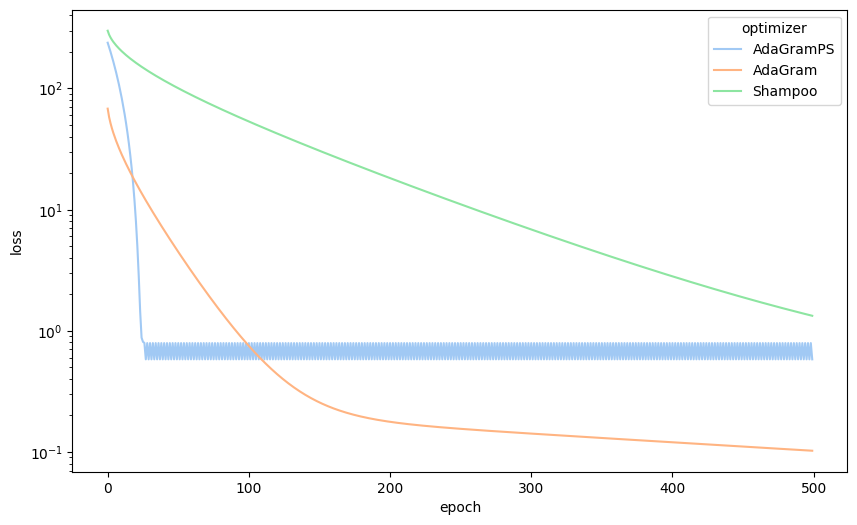

In [6]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df,
    x='epoch',
    y='loss',
    hue='optimizer',
    errorbar=('ci', 95),  # Explicit confidence interval specification
    # estimator='mean',      # Show mean across runs
    palette='pastel',     # Better color scheme
    linewidth=1.5
)

plt.yscale('log')
plt.show()